# 18회차 기출

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, plot_roc_curve, roc_auc_score, roc_curve, f1_score
from sklearn import set_config
set_config(display="diagram")

## 문제 1

**Data descriptions**

Zillow의 집값에 대한 데이터로 각 행은 고유한 주택을 나타냅니다. 주어진 설명변수로 주택가격 범위를 예측하는 다중분류 문제입니다.

-   uid: A unique identifier
-   city: 텍사스 주 오스틴 주변 마을
-   description: Zillow list에 대한 설명
-   latitude: Latitude
-   longitude: Longitude
-   garageSpaces: 차고의 수
-   hasSpa: spa 공간의 유무
-   yearBuilt: 건축년도
-   numOfPatioAndPorchFeatures: patio or 베란다의 개수
-   lotSizeSqFt: 거실 포함 부동산 부지 크기\
-   avgSchoolRating: 학교 유형에 따른 평균 학교 등급
-   MedianStudentsPerTeacher: Zillow list에 있는 모든 학교의 교사당 학생 수 중앙값
-   numOfBathrooms: 욕실의 수
-   numOfBedrooms: 침실의 수
-   priceRange: price ranges

In [2]:
dat = pd.read_csv("problem1.csv")
dat = dat.drop(['description', 'uid'], axis = 1)
dat.columns = dat.columns.str.strip().str.lower().str.replace(' ', '_')

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        10000 non-null  object 
 1   hometype                    10000 non-null  object 
 2   latitude                    10000 non-null  float64
 3   longitude                   10000 non-null  float64
 4   garagespaces                10000 non-null  int64  
 5   hasspa                      10000 non-null  bool   
 6   yearbuilt                   10000 non-null  int64  
 7   numofpatioandporchfeatures  10000 non-null  int64  
 8   lotsizesqft                 10000 non-null  float64
 9   avgschoolrating             10000 non-null  float64
 10  medianstudentsperteacher    10000 non-null  int64  
 11  numofbathrooms              10000 non-null  float64
 12  numofbedrooms               10000 non-null  int64  
 13  pricerange                  1000

In [4]:
y = dat['pricerange']
X = dat.drop(['pricerange'], axis = 1)

**1. EDA를 실시하시오(시각화 포함).**

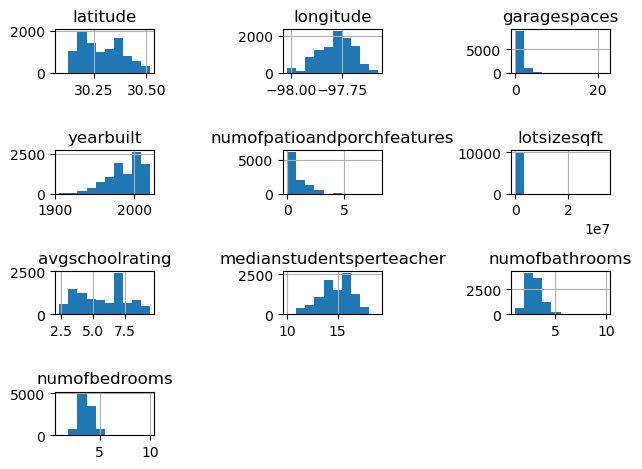

In [5]:
dat.select_dtypes(include=['number']).hist()
plt.subplots_adjust(top=0.9, hspace = 0.9, wspace = 0.5);
plt.tight_layout()
plt.show();

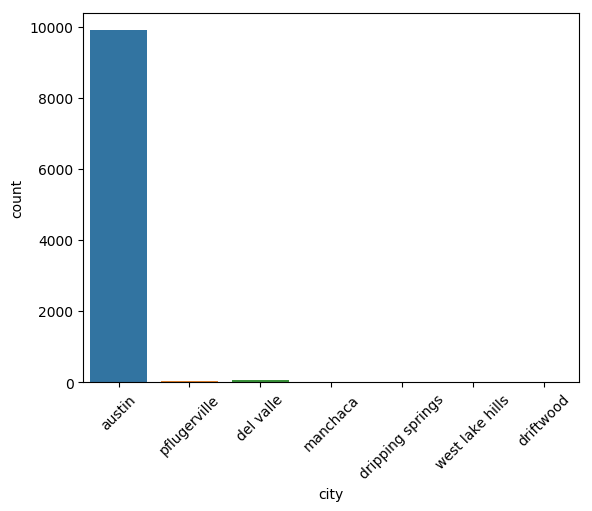

In [6]:
sns.countplot(dat['city']);
plt.xticks(rotation=45);
plt.show();

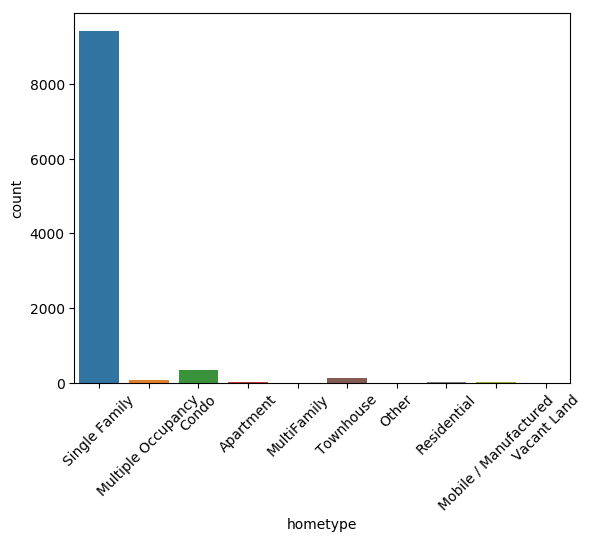

In [7]:
sns.countplot(dat['hometype']);
plt.xticks(rotation=45);
plt.show();

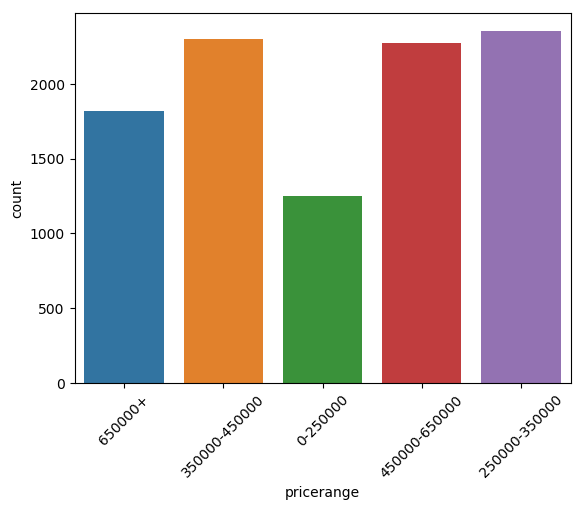

In [8]:
sns.countplot(dat['pricerange']);
plt.xticks(rotation=45);
plt.show();

EDA 해석 생략

**2. 결측치를 처리하시오.**

In [9]:
dat.isna().sum()

city                          0
hometype                      0
latitude                      0
longitude                     0
garagespaces                  0
hasspa                        0
yearbuilt                     0
numofpatioandporchfeatures    0
lotsizesqft                   0
avgschoolrating               0
medianstudentsperteacher      0
numofbathrooms                0
numofbedrooms                 0
pricerange                    0
dtype: int64

데이터에 결측치는 존재하지 않는다.

**3. 파생변수를 2개 생성하고, 생성 이유를 기술하시오.**

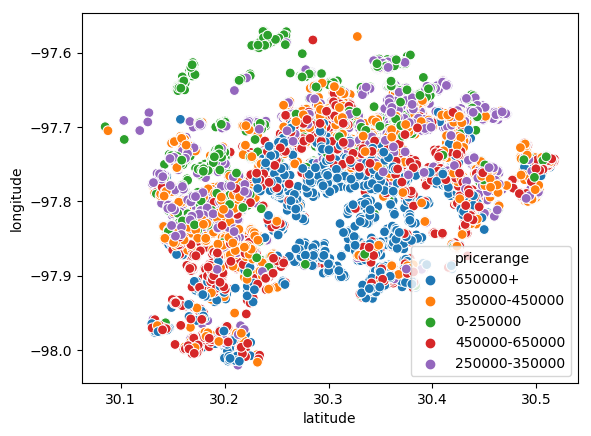

In [10]:
sns.scatterplot(x='latitude', 
                y='longitude', 
                hue='pricerange',
                s=50, # marker size
                data=dat);
plt.show();

위도, 경도를 기준으로 주택 가격에 관한 범주형 변수를 생성한다.

In [11]:
dat['location'] = np.where(dat['longitude'] >= -97.7, 1, 
np.where((dat['latitude']<=30.2) &(dat['longitude']<= -97.7), 2, 3))

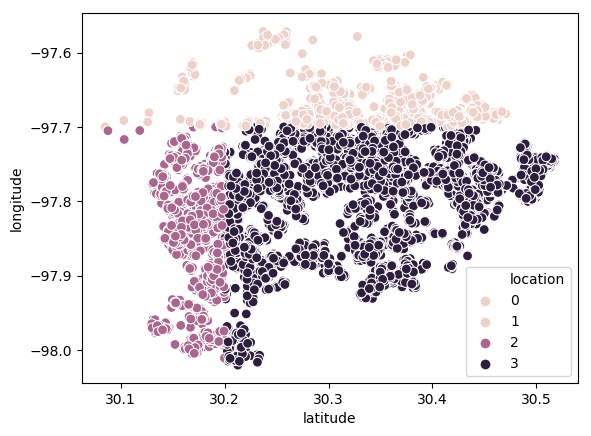

In [12]:
sns.scatterplot(x='latitude', 
                y='longitude', 
                hue='location',
                s=50, # marker size
                data=dat);
plt.show();

In [13]:
freq = dat['hometype'].value_counts(normalize = True)
prob_columns = dat['hometype'].map(freq)
dat['hometype'] = dat['hometype'].mask(prob_columns < 0.1, 'other')
dat['hometype'].value_counts()

Single Family    9427
other             573
Name: hometype, dtype: int64

In [14]:
freq = dat['city'].value_counts(normalize = True)
prob_columns = dat['city'].map(freq)
dat['city'] = dat['city'].mask(prob_columns < 0.1, 'other')
dat['city'].value_counts()

austin    9898
other      102
Name: city, dtype: int64

범주형 변수에 대해서 원핫 인코딩을 수행한다. 연속형 변수에 대해서 표준화를 수행한다. 

In [15]:
num_columns = X.select_dtypes('number').columns.tolist()
cat_columns = X.select_dtypes(['object', 'bool']).columns.tolist()

cat_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

num_preprocess = make_pipeline(
    StandardScaler()
)


preprocess = ColumnTransformer(
    [
     ("num", num_preprocess, num_columns),
     ("cat", cat_preprocess, cat_columns)
     ]
)

pre_dat_X = preprocess.fit_transform(X)

**4. train/test를 7:3으로 분할하시오.**

price_range는 클래스 불균형이 존재하므로, 층화추출을 진행한다.

In [16]:
train_X, test_X, train_y, test_y = train_test_split(pre_dat_X, y, test_size = 0.2, stratify = y, random_state = 0)

**5. SOM을 실시하고, confusion matrix를 출력하시오.**

SOM 모델을 적합한다. 모델 튜닝은 파라미터의 범위를 제한하여 진행하였으며, 반복 5-fold 교차검증을 통해 validation 데이터를 여러번 생성 후 적합하여, 하이퍼파라미터별 모형 성능을 교차 검증하였다.

In [17]:
from minisom import MiniSom  

In [18]:
def classify(som, data):
    """Classifies each sample in data in one of the classes definited
    using the method labels_map.
    Returns a list of the same length of data where the i-th element
    is the class assigned to data[i].
    """
    winmap = som.labels_map(train_X, train_y)
    default_class = np.sum(list(winmap.values())).most_common()[0][0]
    result = []
    for d in data:
        win_position = som.winner(d)
        if win_position in winmap:
            result.append(winmap[win_position].most_common()[0][0])
        else:
            result.append(default_class)
    return result

In [19]:
som = MiniSom(10, 10, train_X.shape[1], sigma=3, learning_rate=0.5, 
              neighborhood_function='triangle', random_seed=10)
              
som.pca_weights_init(train_X) # numpy.array로 넣어줘야됨
som.train_random(train_X, 500, verbose=False)
print(classification_report(test_y, classify(som, test_X)))

C:\Users\alberto\anaconda3\envs\ADP\lib\site-packages\minisom.py:448: ComplexWarning: Casting complex values to real discards the imaginary part
  c2*pc[pc_order[1]]


               precision    recall  f1-score   support

     0-250000       0.54      0.30      0.38       250
250000-350000       0.44      0.56      0.49       471
350000-450000       0.39      0.34      0.37       460
450000-650000       0.42      0.45      0.43       455
      650000+       0.60      0.61      0.60       364

     accuracy                           0.46      2000
    macro avg       0.48      0.45      0.46      2000
 weighted avg       0.46      0.46      0.46      2000



**6. Random forest, 다층신경망 포함 분류모형을 4개 구축하고, F1 score, ROC curve를 생성하시오.**

In [20]:
cat_encoder = preprocess.named_transformers_["cat"]["onehotencoder"]
cat_names = list(cat_encoder.get_feature_names())
full_name = num_columns + cat_names
train_X = pd.DataFrame(train_X, columns = full_name)
test_X = pd.DataFrame(test_X, columns = full_name)

C:\Users\alberto\anaconda3\envs\ADP\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [21]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

**Random forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier
RandomForest_param = {'classifier__max_features': np.arange(0.5, 1, 0.1)}
rf_pipe = Pipeline(
    [
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

RandomForest_search = GridSearchCV(estimator = rf_pipe, 
                      param_grid = RandomForest_param, 
                      cv = cv,
                      scoring = 'balanced_accuracy')
RandomForest_search.fit(train_X, train_y)
print('RandomForest best score : ', RandomForest_search.best_score_)

RandomForest best score :  0.6070264172412683


**mlp**

모델 학습 속도 개선 및 성능 개선을 위해 데이터 전처리로 표준화를 적용한다.

In [23]:
from sklearn.neural_network import MLPClassifier

mlp_pipe = Pipeline(
    [
        ("classifier", MLPClassifier())
    ]
)

MLP_param = {'classifier__learning_rate_init': np.arange(0.01, 0.2, 0.02)}

MLP_search = GridSearchCV(estimator = mlp_pipe, 
                      param_grid = MLP_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
MLP_search.fit(train_X, train_y)
print('MLP best score : ', MLP_search.best_score_)

MLP best score :  0.5813835950019495


**lightgbm**

In [24]:
from lightgbm import LGBMClassifier

pipe_lgb = Pipeline(
    [
        ("classifier", LGBMClassifier())
    ]
)
#LGBMClassifier().get_params()
lgb_param = {'classifier__learning_rate': np.arange(0.01, 0.3, 0.05)}

lgb_search = GridSearchCV(estimator = pipe_lgb, 
                      param_grid = lgb_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
lgb_search.fit(train_X, train_y)
print('LGBM best score : ', lgb_search.best_score_)

LGBM best score :  0.6111074372655338


**Decision tree**

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline(
    [
        ("classifier", DecisionTreeClassifier()) # defaut : 'ovr'
    ]
)

decisiontree_param = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)}

decisiontree_search = GridSearchCV(estimator = dt_pipe, 
                      param_grid = decisiontree_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
decisiontree_search.fit(train_X, train_y)
print('decision tree best score : ', decisiontree_search.best_score_)

decision tree best score :  0.2


balanced accuracy 비교 결과 Random forest 모형을 선택한다.

In [26]:
pred_rf = RandomForest_search.predict(test_X)
print(classification_report(test_y, pred_rf))
print(balanced_accuracy_score(test_y, pred_rf))

               precision    recall  f1-score   support

     0-250000       0.67      0.52      0.59       250
250000-350000       0.59      0.63      0.61       471
350000-450000       0.51      0.51      0.51       460
450000-650000       0.56      0.58      0.57       455
      650000+       0.75      0.75      0.75       364

     accuracy                           0.60      2000
    macro avg       0.61      0.60      0.60      2000
 weighted avg       0.60      0.60      0.60      2000

0.5991623827478716


최종 검증 데이터에서의 성능은 balanced_accuracy = 0.59인 것을 확인할 수 있다.

**ROC curve**

In [27]:
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import roc_curve, auc

In [28]:
y_score = RandomForest_search.predict_proba(test_X)
test_y.value_counts()
y_index = {'0-250000': 0, '250000-350000': 1, '350000-450000': 2, '450000-650000': 3, '650000+': 4}

test_y = [y_index[item] for item in test_y]

y_test_bin = label_binarize(test_y, classes=[0, 1, 2, 3, 4])
n_classes = y_test_bin.shape[1]

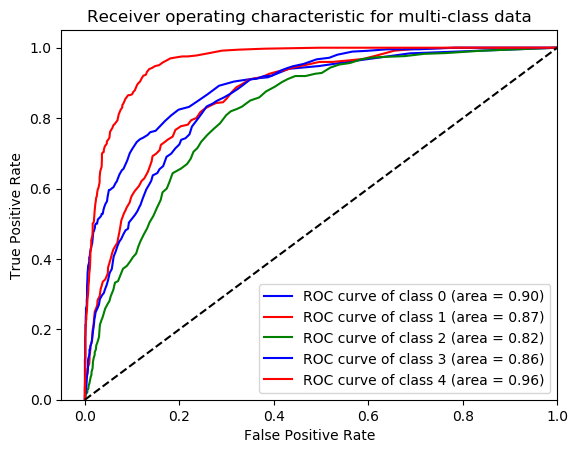

In [29]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]));
             
plt.plot([0, 1], [0, 1], 'k--');
plt.xlim([-0.05, 1.0]);
plt.ylim([0.0, 1.05]);
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate');
plt.title('Receiver operating characteristic for multi-class data');
plt.legend(loc="lower right");
plt.show();

## 문제 2

**빈출명사 top10을 bar chart로 시각화하시오.**

In [30]:
file = open("problem2.txt", mode='r', encoding='cp949')
doc = file.read()
file.close()

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
matrix = vectorizer.fit_transform([doc])
word_counts = pd.DataFrame(matrix.toarray(),
                      columns=vectorizer.get_feature_names())

C:\Users\alberto\anaconda3\envs\ADP\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


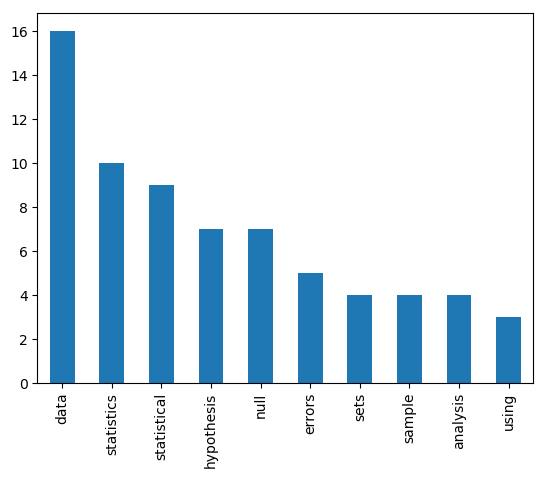

In [32]:
(
word_counts
           .T
           .sort_values(by=0, ascending=False)
           .head(10)
           .plot(kind = 'bar', legend = False)
)
plt.show();

## 문제 3

**Data description**

시뮬레이션 데이터이므로 생략


In [33]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, acf, plot_pacf, pacf

In [34]:
dat = pd.read_csv('problem3.csv')

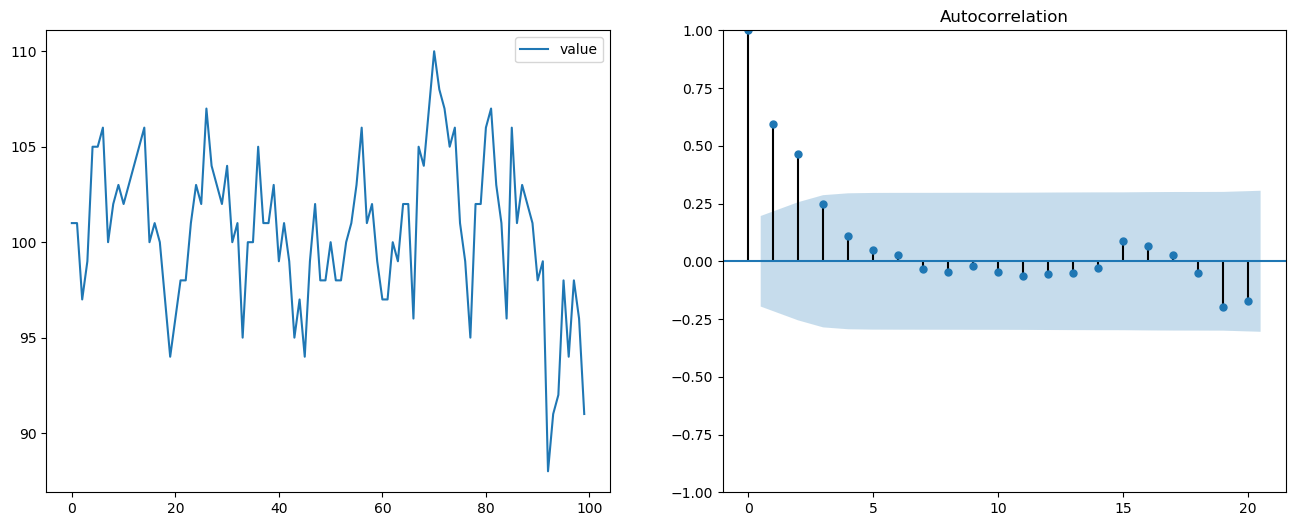

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6));
dat.plot(ax = ax1);
plot_acf(dat.value, ax2);
plt.show();

데이터를 확인해보면 추세가 존재하지 않는 무작위 변동 형태이므로, 정상성을 만족한다.


In [36]:
from statsmodels.tsa.stattools import kpss
print('test statistic: %f' % kpss(dat)[0])
print('p-value: %f' % kpss(dat)[1])

test statistic: 0.169926
p-value: 0.100000


C:\Users\alberto\anaconda3\envs\ADP\lib\site-packages\statsmodels\tsa\stattools.py:2023: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warn_msg.format(direction="greater"), InterpolationWarning
C:\Users\alberto\anaconda3\envs\ADP\lib\site-packages\statsmodels\tsa\stattools.py:2023: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warn_msg.format(direction="greater"), InterpolationWarning


-   귀무 가설 : 데이터가 정상성을 만족한다. 

-   대립 가설 : 데이터가 정상성을 만족하지 않는다. 

kpss test 결과 유의수준 0.05에서 p-value = 0.1 로 크기 때문에 귀무가설을 기각할 수 없다. 따라서 해당 데이터는 정상성을 만족한다. 


**1. ARIMA 모델 3가지를 제시하시오.**

ACF, PACF 그래프를 통해 모델을 인식하면 다음과 같다.

**AR(1)**

-   ACF 감소, PACF 1차 시점 이후 절단

In [37]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(dat, order=(1,0,0), trend = 'c').fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -257.078
Date:                Sun, 20 Jul 2025   AIC                            520.156
Time:                        14:01:11   BIC                            527.972
Sample:                             0   HQIC                           523.319
                                - 100                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.4527      0.864    116.330      0.000      98.760     102.145
ar.L1          0.6231      0.089      7.038      0.000       0.450       0.797
sigma2         9.9620      1.177      8.462      0.000       7.655      12.269
===================================================================================
Ljung-Box (L1) (Q):                   1.05   Jarque-Bera (JB):                 5.61
Prob(Q):                              0.31   Prob(JB):                         0.06
Heteroskedasticity (H):               2.80   Skew:                            -0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

-   귀무 가설: 해당 계수는 0이다.
-   대립 가설: 해당 계수는 0이 아니다.

계수에 대한 신뢰구간을 확인해본 결과, 유의수준 5%에서 절편, ar1 모두 신뢰구간에 0을 포함하지 않으므로, 귀무가설을 기각한다. 따라서 모든 계수가 통계적으로 유의하다.

**auto.arima**

모델 탐색을 위해 auto.arima를 활용한다.

In [38]:
import pmdarima as pm

In [39]:
model2 = pm.auto_arima(dat.value, 
                   start_p=0, 
                   start_q=0,
                   max_p=5, 
                   max_q=5,
                   m=1,          
                   seasonal=False,   
                   start_P=0, 
                   D=None, 
                   trace=True,
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1208.175, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=535.268, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=536.654, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=537.266, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=538.261, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=520.136, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=539.552, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=520.164, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=520.152, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=517.986, Time=0.17 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=523.566, Time=0.04 s

aic를 기준으로 절편이 포함된 ARIMA(1, 0, 2)모델이 선택된다.

In [40]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  100
Model:               SARIMAX(1, 0, 2)   Log Likelihood                -253.993
Date:                Sun, 20 Jul 2025   AIC                            517.986
Time:                        14:01:13   BIC                            531.012
Sample:                             0   HQIC                           523.258
                                - 100                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     46.0062     17.709      2.598      0.009      11.297      80.716
ar.L1          0.5421      0.177      3.069      0.002       0.196       0.888
ma.L1         -0.0109      0.186     -0.058      0.954      -0.376       0.354
ma.L2          0.2921      0.147      1.990      0.047       0.004       0.580
sigma2         9.3514      1.177      7.946      0.000       7.045      11.658
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.96
Prob(Q):                              0.95   Prob(JB):                         0.08
Heteroskedasticity (H):               2.39   Skew:                            -0.30
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

-   귀무 가설: 해당 계수는 0이다.
-   대립 가설: 해당 계수는 0이 아니다.

계수에 대한 신뢰구간을 확인해본 결과, 유의수준 5%에서 ma.L1이 신뢰구간에 0을 포함하므로, 귀무가설을 기각할 수 없다. 따라서 ma.L1 계수는 통계적으로 비유의하다.

ma.L1  계수가 제거된 ARIMA(1, 0, 2) 모델이 선택된다.

In [41]:
model3 = ARIMA(dat.value, order=(1, 0, [0, 1]), trend ='c').fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  value   No. Observations:                  100
Model:               ARIMA(1, 0, [2])   Log Likelihood                -253.993
Date:                Sun, 20 Jul 2025   AIC                            515.987
Time:                        14:01:13   BIC                            526.408
Sample:                             0   HQIC                           520.204
                                - 100                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.4733      0.883    113.777      0.000      98.742     102.204
ar.L1          0.5315      0.112      4.756      0.000       0.312       0.751
ma.L2          0.2974      0.139      2.148      0.032       0.026       0.569
sigma2         9.3483      1.157      8.083      0.000       7.081      11.615
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.01
Prob(Q):                              0.95   Prob(JB):                         0.08
Heteroskedasticity (H):               2.39   Skew:                            -0.30
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

-   귀무 가설: 해당 계수는 0이다.
-   대립 가설: 해당 계수는 0이 아니다.

계수에 대한 신뢰구간을 확인해본 결과, 유의수준 5%에서 모든 계수가 신뢰구간에 0을 포함하지 않으므로, 귀무가설을 기각한다. 따라서 모든 계수가 통계적으로 유의하다.

**2. 최적 모델 선택을 선택하고, 이유를 설명하시오.**

In [42]:
print(model.bic)
print(model2.bic())
print(model3.bic)

527.9718738182713
531.0121901843172
526.407590714031


BIC를 기준으로 ma1 계수가 제거된 ARIMA(1, 0, 2) 모델이 선택된다.

**3. 선행 시차까지 예측을 실시하고, 시각화하시오**

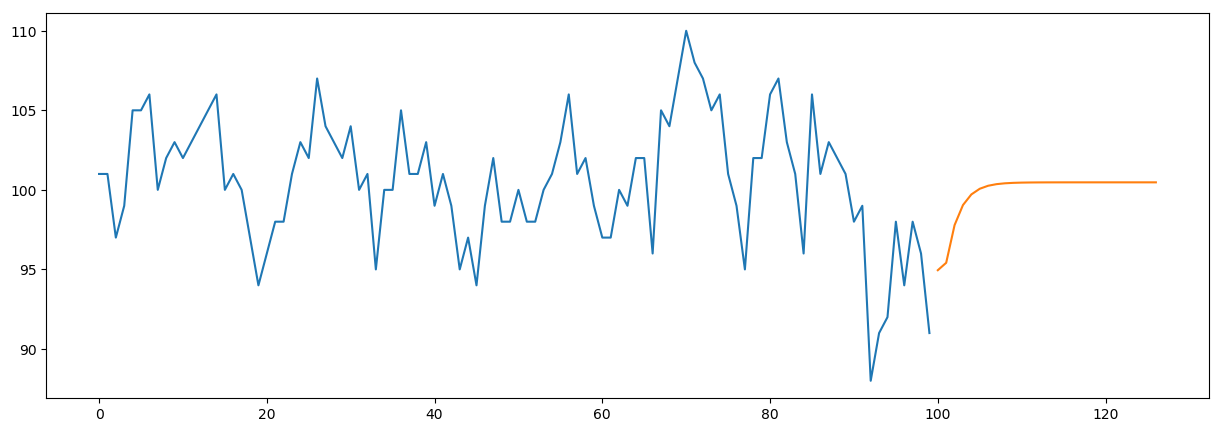

In [43]:
fore = model3.forecast(steps=27, alpha=0.05)
fig, ax = plt.subplots(1, 1, figsize = (15, 5));
ax.plot(dat.value);
ax.plot(fore);
plt.show();